# 第023单元 线性模型与最小训练闭环

固定合成数据上的教学Notebook。目标：手算一轮、写全批次梯度、检查形状和收敛，并与训练均值常数及数值最小二乘比较。先修009、011、014、020。

默认运行的训练/验证/测试MSE为7/60、9/320、2/25；它们是固定网格结果，不是未知总体保证。先自己计算，再运行下方核验。

## 环境与固定教学契约

需Python、NumPy、Jupyter；图像显示使用IPython。本目录含environment.yml安装建议。在单元目录启动，重启内核并从第一格运行。作者以新Python进程中的真实InProcessKernel执行；全新Anaconda、浏览器UI与跨进程socket传输未测试。首个计算检查原始数据、配置与现有输出，不匹配时不创建Notebook输出。

In [1]:
from pathlib import Path
import json
import numpy as np
import experiment as e
assert Path.cwd().resolve() == e.BASE, '请在本单元目录启动 Notebook'
summary_fixed, trace_fixed, predictions_fixed, checks_fixed = e.teaching_payload()
print('固定教学配置与数据/结果核对通过；尚未写 Notebook 结果。')
print('NumPy:', np.__version__)

固定教学配置与数据/结果核对通过；尚未写 Notebook 结果。
NumPy: 2.3.5


## 一 三条样本的形状

预测与标签都用一维向量。A末列为1，参数顺序是w、b。

In [2]:
X_small = np.array([[-1.0], [0.0], [1.0]])
y_small = np.array([-1.0, 1.0, 3.0])
A_small = e.design(X_small)
theta0 = np.zeros(2)
print('X, A, y, theta:', X_small.shape, A_small.shape, y_small.shape, theta0.shape)
print(A_small)

X, A, y, theta: (3, 1) (3, 2) (3,) (2,)
[[-1.  1.]
 [ 0.  1.]
 [ 1.  1.]]


## 二 先看梯度再更新

L是半MSE。下方同时保存旧状态和新状态；一轮更新对应两行。

In [3]:
loss0, gradient0 = e.loss_gradient(X_small, y_small, theta0)
end_small, trace_small = e.train(X_small, y_small, .5, 1, theta0)
assert np.allclose(gradient0, [-4/3, -1])
assert np.allclose(end_small, [2/3, 1/2])
assert abs(trace_small[1]['loss'] - 155/216) < 1e-14
print('初始损失和梯度:', loss0, gradient0)
print('新参数:', end_small, '新损失:', trace_small[1]['loss'])

初始损失和梯度: 1.8333333333333333 [-1.33333333 -1.        ]
新参数: [0.66666667 0.5       ] 新损失: 0.7175925925925927


## 三 主动制造形状错误

完全正确的预测不应有误差。注意广播得到的不是逐样本残差。

In [4]:
perfect = np.array([-1., 1., 3.])
correct = perfect - y_small
wrong = perfect[:, None] - y_small
print('正确:', correct.shape, np.mean(correct**2))
print('错误:', wrong.shape, np.mean(wrong**2))
print(wrong)
assert np.isclose(np.mean(wrong**2), 16/3)

正确: (3,) 0.0
错误: (3, 3) 5.333333333333333
[[ 0. -2. -4.]
 [ 2.  0. -2.]
 [ 4.  2.  0.]]


## 四 读取固定拆分和训练均值

训练12行、验证8行、测试10行。只用训练标签拟合常数，后续全部拆分使用同一常数。

In [5]:
rows = e.load_samples(e.BASE / 'data/samples.csv')
X_train, y_train = e.split_arrays(rows, 'train')
print({s: sum(r['split']==s for r in rows) for s in e.SPLITS})
print('训练形状:', X_train.shape, y_train.shape)
print('训练均值基线:', y_train.mean())
B = np.sum(e.design(X_train)**2) / len(y_train)
print('B 与充分步长上界:', B, 2/B)

{'train': 12, 'validation': 8, 'test': 10}
训练形状: (12, 2) (12,)
训练均值基线: 2.5
B 与充分步长上界: 5.166666666666667 0.3870967741935484


## 五 非最优点的梯度检查

绝对误差与带尺度底限的误差都要看。二次函数中心差分无精确算术截断误差，但仍存在浮点舍入。

In [6]:
checks = e.gradient_check(X_train, y_train, [0.4, -0.2, 0.7], 1e-5)
for row in checks:
    print(row)
assert max(r['scaled_error'] for r in checks) < 1e-8

{'coordinate': 0, 'analytic': -5.466666666666666, 'finite_difference': -5.466666666675834, 'absolute_error': 9.167777648144693e-12, 'scaled_error': 1.6770324966090218e-12}
{'coordinate': 1, 'analytic': 0.5500000000000002, 'finite_difference': 0.550000000032469, 'absolute_error': 3.246880542207009e-11, 'scaled_error': 3.246880542207009e-11}
{'coordinate': 2, 'analytic': -1.6000000000000003, 'finite_difference': -1.599999999957191, 'absolute_error': 4.2809311651126336e-11, 'scaled_error': 2.6755819781953954e-11}


## 六 同一训练目标的数值参照

直接lstsq，不构造正规方程逆。残差摘要可为空，所以函数重新计算真实损失。

In [7]:
reference, info = e.least_squares(X_train, y_train)
print('参照参数:', reference)
print('数值秩:', info['rank'], '半MSE:', info['loss'])
assert np.allclose(reference, [2., -.75, 1.5])
assert np.isclose(info['loss'], 7/120)

参照参数: [ 2.   -0.75  1.5 ]
数值秩: 3 半MSE: 0.058333333333333286


## 七 运行并保存最小训练闭环

所有输入检查、计算和序列化通过后才写notebook_outputs四文件。会覆盖该目录同名输出；与发布结果分开存放。

In [8]:
summary = e.run(output=e.BASE / 'notebook_outputs')
print('最终参数:', summary['theta'])
print('最终梯度范数:', summary['final_gradient_norm'])
print('与参照的最大训练预测差:', summary['max_training_prediction_difference'])
assert summary['final_gradient_norm'] < 1e-10
assert summary['max_training_prediction_difference'] < 2e-12

最终参数: [2.0000000000001585, -0.749999999999986, 1.4999999999992786]
最终梯度范数: 6.576448330814683e-13
与参照的最大训练预测差: 1.0536016503692736e-12


## 八 读轨迹与非零平台

301行包括初始状态和300次更新后的状态。图的左轴是半MSE；不要误读为完整MSE。

初始、最终目标: 9.297916666666667 0.05833333333333337


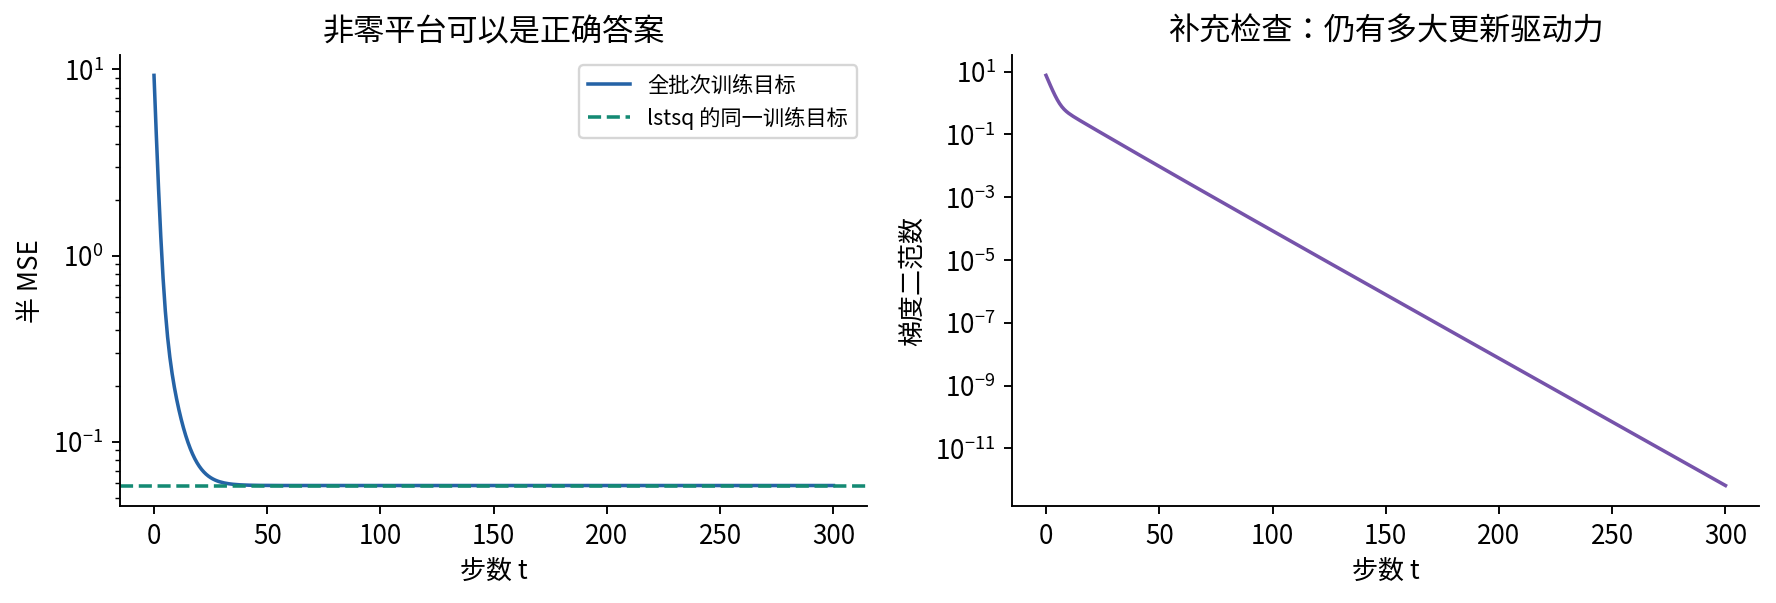

In [9]:
from IPython.display import display, Image
assert len(trace_fixed) == 301
assert all(b['loss'] <= a['loss'] + 2e-14 for a,b in zip(trace_fixed, trace_fixed[1:]))
print('初始、最终目标:', trace_fixed[0]['loss'], trace_fixed[-1]['loss'])
display(Image(filename=str(e.BASE / 'figures/06_convergence.png')))

## 九 使用同一MSE评价三个拆分

固定预算已完成后再看评价；本讲没有根据验证/测试选模型或步数。验证误差较小来自不同输入网格和交互幅度。

train 模型MSE= 0.11666666666666674 常数MSE= 12.345833333333331
validation 模型MSE= 0.028124999999999935 常数MSE= 11.418750000000001
test 模型MSE= 0.08000000000000006 常数MSE= 8.6425


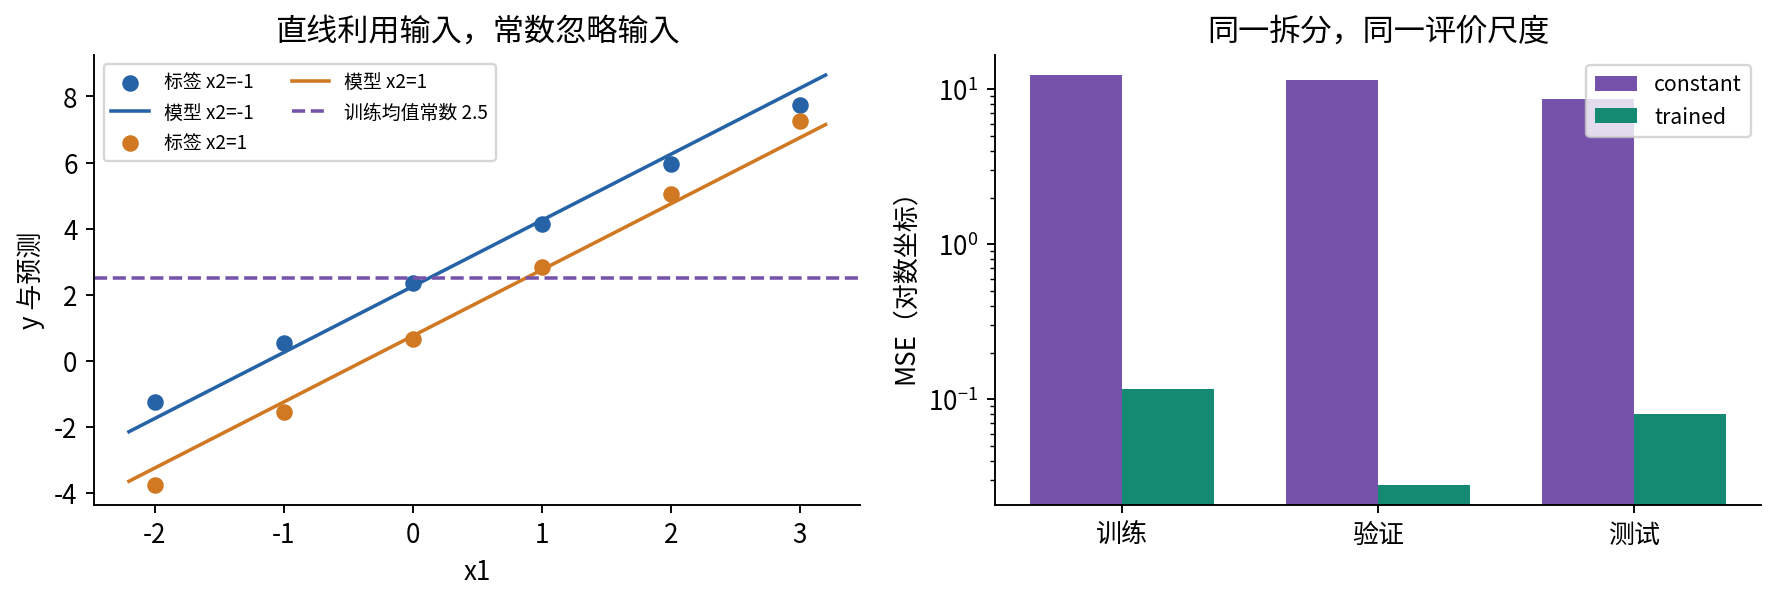

In [10]:
for split in e.SPLITS:
    s = summary['mse'][split]
    print(split, '模型MSE=', s['trained'], '常数MSE=', s['constant'])
display(Image(filename=str(e.BASE / 'figures/07_baseline.png')))

## 十 解释残差而不是强迫零损失

交互项未在模型中出现；残差与三设计列内积为零，但残差本身有规律。

列内积: [-3.10862447e-15 -2.22044605e-15  3.44169138e-15]
训练MSE: 0.11666666666666654


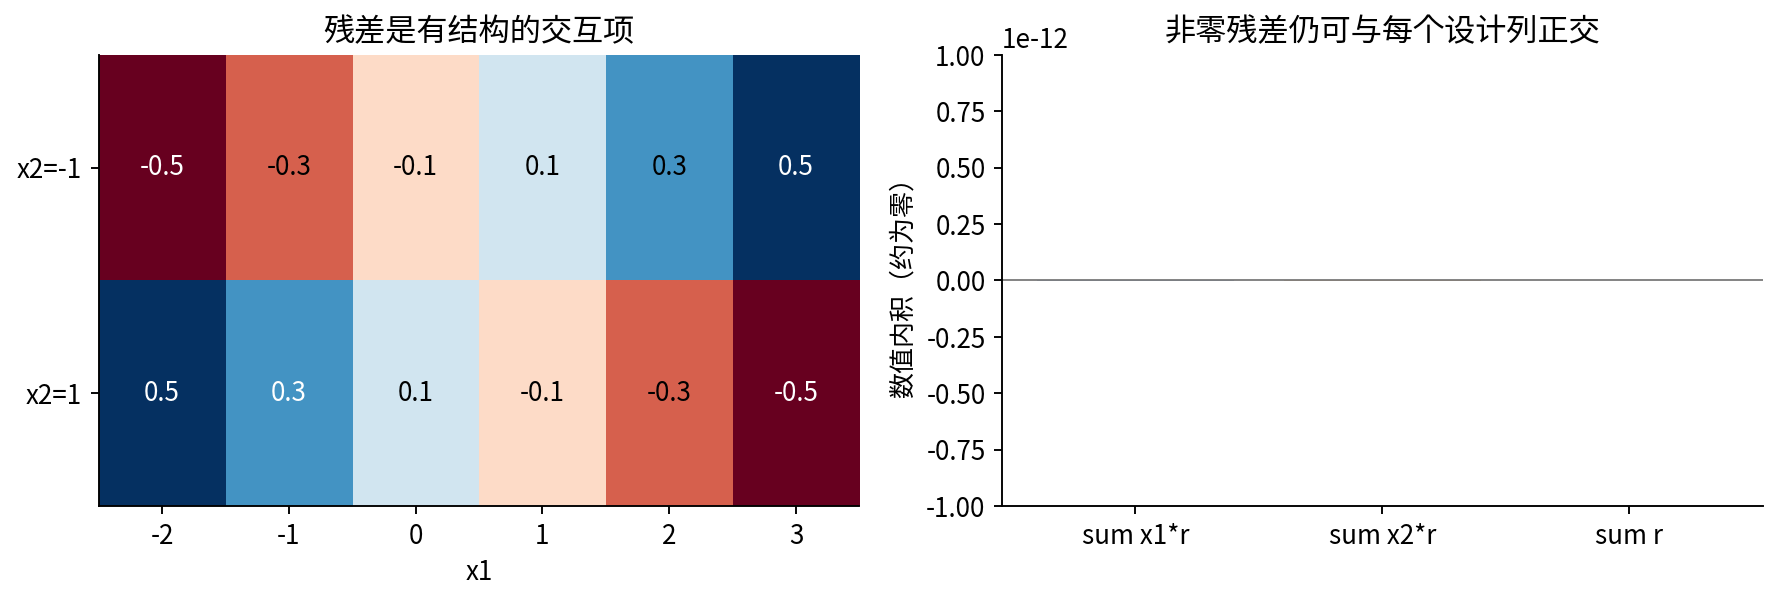

In [11]:
residual = e.predict(X_train, reference) - y_train
print('列内积:', e.design(X_train).T @ residual)
print('训练MSE:', np.mean(residual**2))
assert np.allclose(e.design(X_train).T @ residual, 0, atol=1e-12)
display(Image(filename=str(e.BASE / 'figures/08_residual_structure.png')))

## 十一 非唯一参数与边界步长

重复列使参数不可分辨，非零初始差值保留。另一个单偏置例展示大步长振荡。

In [12]:
X_dup = np.array([[-1., -1.], [0., 0.], [1., 1.]])
theta_dup, _ = e.train(X_dup, y_small, .2, 300, [4., -2., 0.])
ref_dup, ref_info = e.least_squares(X_dup, y_small)
print('梯度下降:', theta_dup, 'lstsq:', ref_dup, '秩:', ref_info['rank'])
assert np.allclose(e.predict(X_dup, theta_dup), e.predict(X_dup, ref_dup))
for eta in [.5, 2., 2.1]:
    _, path = e.train([[0]], [1], eta, 22, [0,0])
    print('eta=', eta, '最终半MSE=', path[-1]['loss'])

梯度下降: [ 4. -2.  1.] lstsq: [1. 1. 1.] 秩: 2
eta= 0.5 最终半MSE= 2.842170943040401e-14
eta= 2.0 最终半MSE= 0.5
eta= 2.1 最终半MSE= 33.13203803868337


## 十二 独立测试和逐字节重现

Fraction参照不调用生产梯度或浮点最小二乘来生成期望值。核心测试也检查失败之前不产生输出。

In [13]:
import unittest
import test_experiment
suite = unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
result = unittest.TextTestRunner(verbosity=1).run(suite)
assert result.wasSuccessful()
print('独立测试组数:', result.testsRun)

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 12 tests in 0.837s

OK


独立测试组数: 12


In [14]:
import hashlib
for name in e.OUTPUT_NAMES:
    script_bytes = (e.BASE / 'outputs' / name).read_bytes()
    notebook_bytes = (e.BASE / 'notebook_outputs' / name).read_bytes()
    assert script_bytes == notebook_bytes, name
    print(name, '一致', hashlib.sha256(script_bytes).hexdigest()[:16])

summary.json 一致 3bfb5abea83833c8
trajectory.csv 一致 6d222a71f828b3c2
predictions.csv 一致 519443532535f7b4
gradient_check.csv 一致 739d4b16a88d9fbd


## 结论与后续

在固定合成网格上，梯度与精确/数值参照吻合，训练趋近类内最优，并优于训练均值常数。非零交互残差来自模型表示限制；秩不足时参数差异不必意味预测差异。

继续做lab.md的A至D任务，再核对answers.md。自定义配置用脚本另存，不沿用这套固定图文。资料来源与作者核验范围见source-checks.json和verification.json；未实测全新Anaconda、浏览器UI、socket传输或跨平台安装。